Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 8: Supervised Learning Classification**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score,f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
    )

## 1. Dataset Selection and Preprocessing

**- Load and clean the data**

In [3]:
df = pd.read_csv("extended_data.csv")
# Remove duplicate rows
df = df.drop_duplicates()
# Remove rows with missing target values
df = df.dropna(subset=["msrp"])

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (28126, 8)

Missing values:
model_year          0
brand               0
model               0
type                0
miles_per_gallon    0
premium_version     0
msrp                0
collection_car      0
dtype: int64


**- Define features and split the data**

In [4]:
# Features and target
X = df.drop(columns="msrp")
y = df["msrp"]

# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**- Handle missing features and encode categorical columns**

In [5]:
# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(include="object").columns.tolist()

In [6]:
# Replace missing numerical values with the training median
numerical_transformer = SimpleImputer(strategy="median")

In [7]:
# Fill missing categories and apply one-hot encoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [8]:
# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("numerical", numerical_transformer, numerical_columns),
    ("categorical", categorical_transformer, categorical_columns)
])

In [9]:
# Learn preprocessing rules from training data only
X_train_processed = preprocessor.fit_transform(X_train)
# Apply the same rules to testing data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (22500, 1967)
Processed testing shape: (5626, 1967)


## 2. Exploratory Data Analysis (EDA)

**- Summarize the data**

In [10]:
# Summary statistics for numerical columns
df.describe()

,model_year,miles_per_gallon,premium_version,msrp,collection_car
count,28126.000000,28126.000000,28126.000000,2.812600e+04,28126.000000
mean,2013.457833,21.769242,0.533777,5.736535e+04,0.137382
std,6.848438,13.472177,0.498867,6.146327e+04,0.344256
min,1974.000000,-1.000000,0.000000,0.000000e+00,0.000000
25%,2009.000000,17.000000,0.000000,3.000000e+04,0.000000
50%,2015.000000,20.000000,1.000000,4.120000e+04,0.000000
75%,2019.000000,24.000000,1.000000,6.400000e+04,0.000000
max,2024.000000,234.000000,1.000000,2.500000e+06,1.000000


In [11]:
# Count vehicles in each category
print(df["type"].value_counts())

type
SUV            9972
Sedan          8124
Coupe          4163
Pickup         2959
Convertible    1310
Hatchback       759
Minivan         547
Van             286
Wagon             6
Name: count, dtype: int64


**- Visualize price and category distributions**

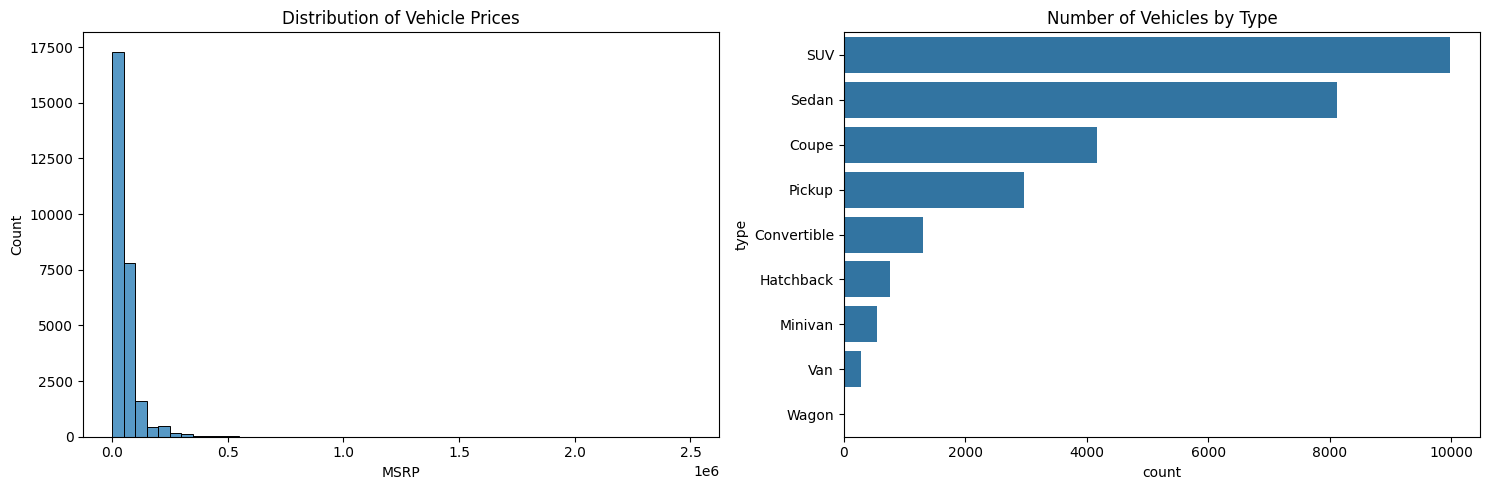

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Target distribution
sns.histplot(data=df, x="msrp", bins=50, ax=axes[0])
axes[0].set_title("Distribution of Vehicle Prices")
axes[0].set_xlabel("MSRP")
# Vehicle category distribution
sns.countplot(data=df, y="type", order=df["type"].value_counts().index, ax=axes[1])
axes[1].set_title("Number of Vehicles by Type")
plt.tight_layout()
plt.show()

**- Examine correlations**

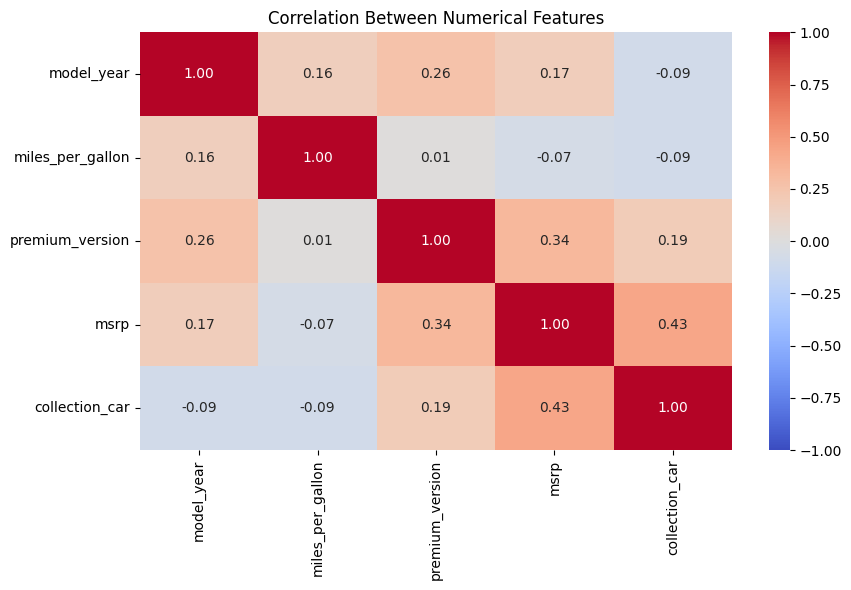

In [13]:
# Calculate correlations between numerical columns
correlation = df.select_dtypes(include="number").corr()
plt.figure(figsize=(9, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f",vmin=-1, vmax=1)
plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

**- Examine relationships and potential outliers**

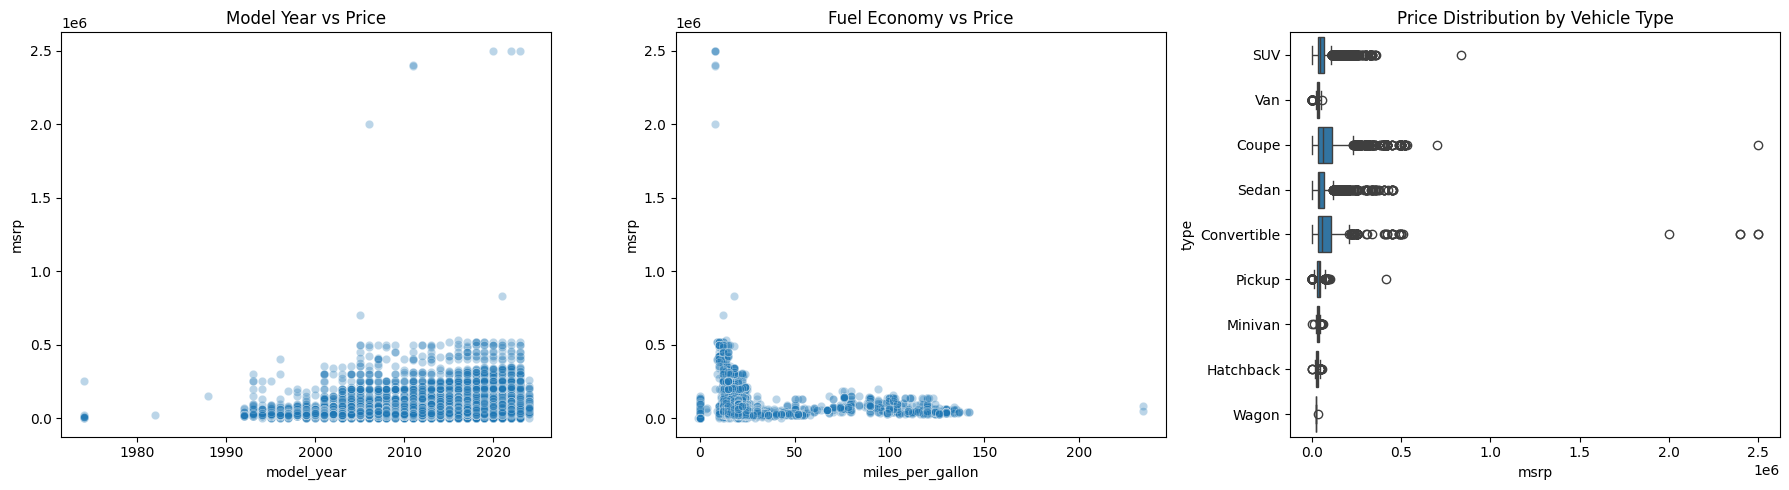

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="model_year", y="msrp", alpha=0.3, ax=axes[0])
axes[0].set_title("Model Year vs Price")

sns.scatterplot(data=df, x="miles_per_gallon", y="msrp", alpha=0.3, ax=axes[1])
axes[1].set_title("Fuel Economy vs Price")

sns.boxplot(data=df, x="msrp", y="type", ax=axes[2])
axes[2].set_title("Price Distribution by Vehicle Type")

plt.tight_layout()
plt.show()

### Insights

The distribution of vehicle prices, potential outliers, and differences between vehicle categories can affect prediction performance. Very expensive vehicles may increase RMSE, so unusual prices should be investigated before removal. If relationships between features and price are nonlinear, a Random Forest regressor may perform better than linear regression. Uneven category sizes and the large number of unique vehicle models may also make predictions less reliable for rare categories. Since the target is a numerical price, model performance should be evaluated using RMSE, MAE, and R-squared rather than classification accuracy.

## 3. Model Implementation and Evaluation

**- Target and preprocessing**

In [15]:
# Define classification features and target
X = df.drop(columns=["premium_version", "msrp"])
y = df["premium_version"].astype(int)
# Split the data while preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Update feature column lists
numerical_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(include="object").columns.tolist()
# Rebuild preprocessing using the existing transformers from Point 1
preprocessor = ColumnTransformer([("numerical", numerical_transformer, numerical_columns),
 ("categorical", categorical_transformer, categorical_columns)])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

**- Implement and train two classifiers**

In [17]:
# Create the models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train both models
decision_tree.fit(X_train_processed, y_train)
random_forest.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

**- Evaluate on the test set**

In [18]:
models = {"Decision Tree": decision_tree, "Random Forest": random_forest}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_probability = model.predict_proba(X_test_processed)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

# Display the comparison
results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.8141,0.8182,0.8378,0.8279,0.8124
Random Forest,0.8660,0.8633,0.8898,0.8764,0.9345


## 4. Model Interpretation and Inference

**- Compare the evaluation metrics**

In [19]:
display(results_df.round(4))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,0.8141,0.8182,0.8378,0.8279,0.8124
Random Forest,0.8660,0.8633,0.8898,0.8764,0.9345


**- Confusion matrices**

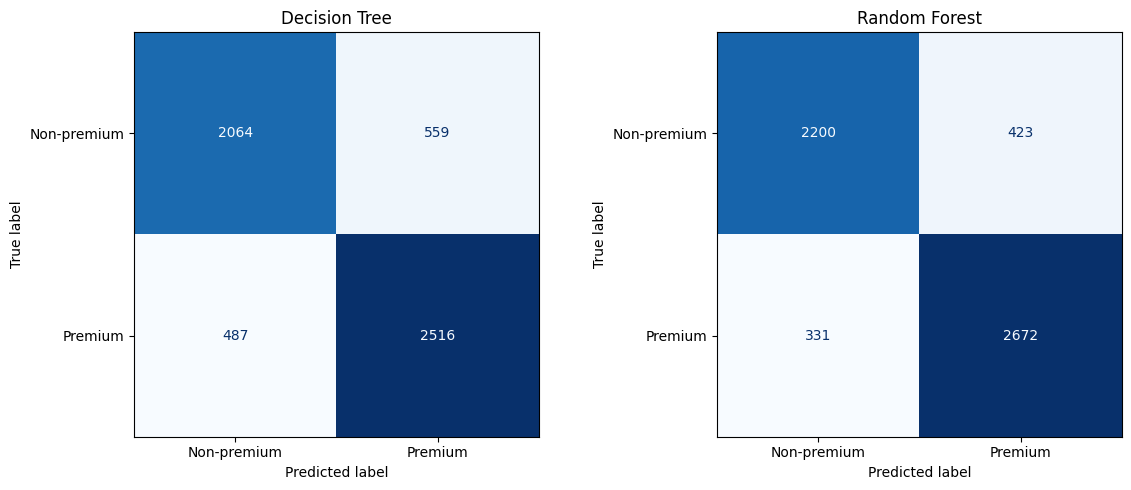

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model,
        X_test_processed,
        y_test,
        display_labels=["Non-premium", "Premium"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

**- Plot ROC curves**

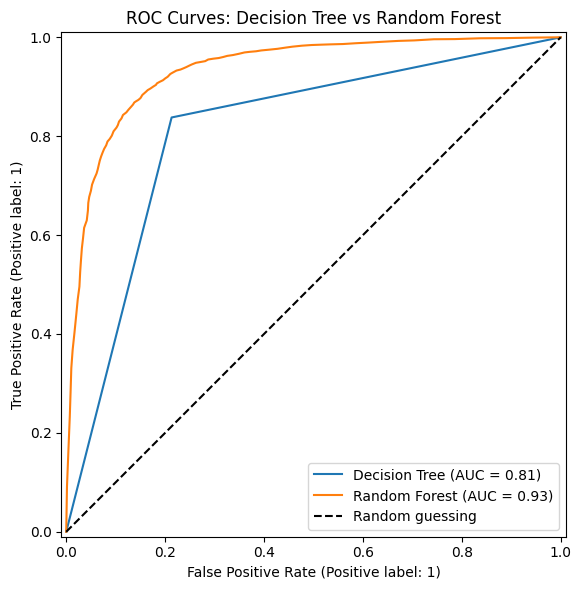

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_processed, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random guessing")
ax.set_title("ROC Curves: Decision Tree vs Random Forest")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Interpretation

The better model should have a higher F1-score and ROC-AUC, showing that it identifies premium vehicles more effectively. The confusion matrices show correct predictions and mistakes, while ROC curves closer to the top-left corner indicate better performance.

## 5. Deployment and Monitoring

#### - Deployment

Deploy the best-performing classifier through a Flask or FastAPI application. Save both the trained model and its fitted preprocessor. The application would accept vehicle details and return a premium or non-premium prediction with its probability.

#### - Potential issues and real-time data

Incoming data may contain missing values, incorrect formats, or unfamiliar vehicle brands and models. Validate each request and apply the same preprocessing used during training. The existing encoder can handle unseen categories without failing, but predictions for unfamiliar vehicles may be less reliable. Monitor response times and handle invalid requests with clear error messages.

#### - Monitoring and maintenance

Track prediction errors, response times, and changes in incoming vehicle data. When actual premium labels become available, calculate precision, recall, and F1-score to check performance. Retrain with updated, labelled data if performance declines, validate the new model before deployment, and retain previous versions so they can be restored if necessary.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
!ls -la "/content/drive/MyDrive"

total 545
drwx------ 5 root root   4096 Sep 13 19:15  .
drwx------ 5 root root   4096 Sep 13 19:15  ..
-rw------- 1 root root    175 Nov 27  2021 'Altyd gefokus - Midterm Exam-Online.gdoc'
-rw------- 1 root root     48 Jan 17  2020  BackupRestoreTest.txt
drwx------ 2 root root   4096 May  3  2021  Classroom
-rw------- 1 root root    175 Oct  3  2024 'Client Intake Form - Fillable - 2024.gdoc'
-rw------- 1 root root 531006 Sep 30  2024 'Client Intake Form - Fillable - 2024.pdf'
drwx------ 2 root root   4096 May  1 12:32 'Colab Notebooks'
-rw------- 1 root root   3815 May 26 15:49  employees.csv
drwx------ 2 root root   4096 Feb 26  2021  Takeout


In [25]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "Assignment_8*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Assignment_8.ipynb


In [26]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 37 (delta 15), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 669.79 KiB | 5.45 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [27]:
!ls -la /content/colab-git-assignment2-ST

total 664
drwxr-xr-x 5 root root   4096 Sep 13 19:21  .
drwxr-xr-x 1 root root   4096 Sep 13 19:21  ..
-rw-r--r-- 1 root root   5415 Sep 13 19:21  assignment2.ipynb
drwxr-xr-x 2 root root   4096 Sep 13 19:21  Assignment_9
drwxr-xr-x 8 root root   4096 Sep 13 19:21  .git
drwxr-xr-x 2 root root   4096 Sep 13 19:21  Lesson_10_assignment
-rw-r--r-- 1 root root  12704 Sep 13 19:21  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root  80271 Sep 13 19:21 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root 549515 Sep 13 19:21  Lesson_5_Assignment.ipynb
